In [1]:
%pip install pandas numpy matplotlib

# https://github.com/marcopeix/TimeSeriesForecastingInPython/blob/master/CH02/CH02.ipynb

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None

In [3]:
df = pd.read_csv('./data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [4]:
# elementos a predecir / pronosticar
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


## Dibujamos los datos con el split de train/test

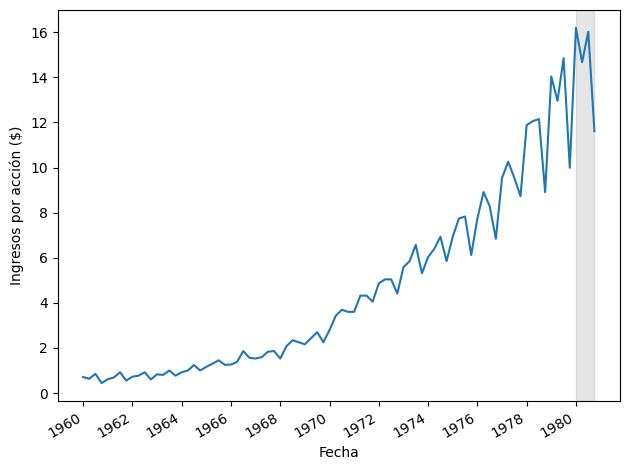

In [5]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.set_xlabel('Fecha')
ax.set_ylabel('Ingresos por acción ($)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('images/CH02_F01.png', dpi=300)

## Split de train/test

In [6]:
train = df[:-4]
test = df[-4:]

In [7]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

In [8]:
# Media histórica - modelo de referencia
# Usamos la media de los datos de entrenamiento como modelo de referencia

historical_mean = np.mean(train['data'])
historical_mean

np.float64(4.308499987499999)

In [9]:
test.loc[:, 'pred_mean'] = historical_mean

test

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


In [10]:
# Calculamos el error cuadrático medio (MSE) del modelo de referencia
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [11]:
mape_hist_mean = mape(test['data'], test['pred_mean'])
print(mape_hist_mean)

70.00752579965119


## Visualizando la predicción

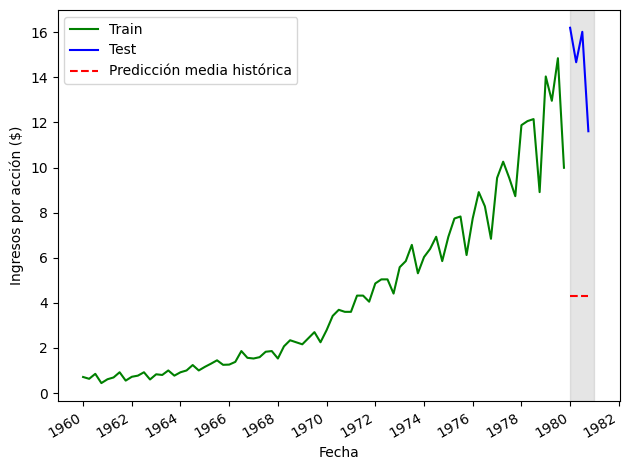

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots()
 
ax.plot(train['date'], train['data'], 'g', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicción media histórica')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ingresos por acción ($)')

# Sombrear el área de test
ax.axvspan(pd.to_datetime('1980-01-01'), pd.to_datetime('1980-12-31'), color='#808080', alpha=0.2)

ax.legend(loc=2)

# Formatear el eje x para mostrar las fechas correctamente
ax.xaxis.set_major_locator(mdates.YearLocator(2))  # Un tick cada 2 años
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Predicción de la media del último año

In [13]:
last_year_mean = np.mean(train['data'][-4:])
last_year_mean

np.float64(12.96)

In [14]:
test.loc[:, 'pred_last_yr_mean'] = last_year_mean

test

,date,data,pred_mean,pred_last_yr_mean
80,1980-01-01,16.20,4.3085,12.96
81,1980-04-01,14.67,4.3085,12.96
82,1980-07-02,16.02,4.3085,12.96
83,1980-10-01,11.61,4.3085,12.96


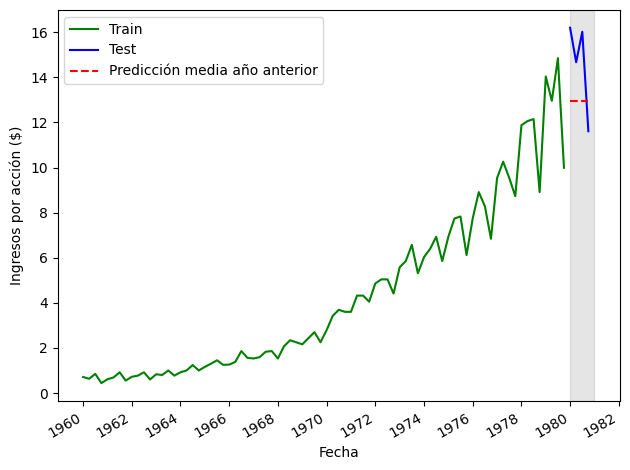

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots()
 
ax.plot(train['date'], train['data'], 'g', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_yr_mean'], 'r--', label='Predicción media año anterior')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ingresos por acción ($)')

# Sombrear el área de test
ax.axvspan(pd.to_datetime('1980-01-01'), pd.to_datetime('1980-12-31'), color='#808080', alpha=0.2)

ax.legend(loc=2)

# Formatear el eje x para mostrar las fechas correctamente
ax.xaxis.set_major_locator(mdates.YearLocator(2))  # Un tick cada 2 años
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Predicción estacionaria

In [16]:
test.loc[:, 'pred_last_season'] = train['data'][-4:].values

test

,date,data,pred_mean,pred_last_yr_mean,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,14.04
81,1980-04-01,14.67,4.3085,12.96,12.96
82,1980-07-02,16.02,4.3085,12.96,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99


In [17]:
mape_naive_seasonal = mape(test['data'], test['pred_last_season'])
mape_naive_seasonal

np.float64(11.561658552433654)

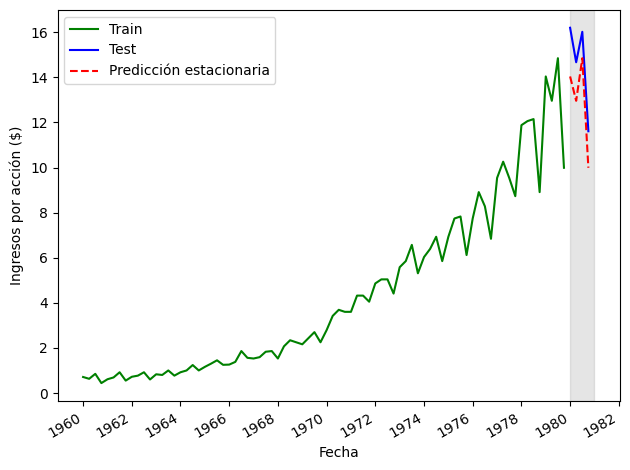

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots()
 
ax.plot(train['date'], train['data'], 'g', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicción estacionaria')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ingresos por acción ($)')

# Sombrear el área de test
ax.axvspan(pd.to_datetime('1980-01-01'), pd.to_datetime('1980-12-31'), color='#808080', alpha=0.2)

ax.legend(loc=2)

# Formatear el eje x para mostrar las fechas correctamente
ax.xaxis.set_major_locator(mdates.YearLocator(2))  # Un tick cada 2 años
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Métricas

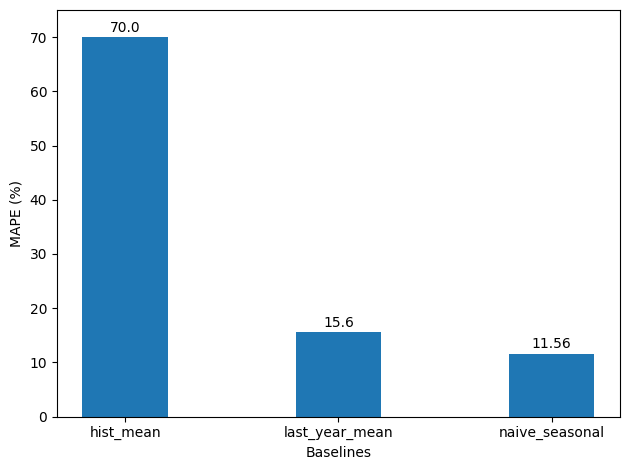

In [19]:
fig, ax = plt.subplots()

x = ['hist_mean', 'last_year_mean', 'naive_seasonal']
y = [70.00, 15.60, 11.56]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Baselines')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 75)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(value), ha='center')

plt.tight_layout()
plt.show()